In [1]:
import pandas as pd
df = pd.read_csv("../data/dataset.csv")

In [2]:
# information abour dataset
print(df.shape)
print(df.info())
print(df.isna().sum().sum(), "missing values in total")
print(df.duplicated().sum(), "duplicate rows")

# what we predict
df["Target"].value_counts()

(4424, 35)
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [3]:
import numpy as np

# Removed exact duplicate rows
df_clean = df.copy().drop_duplicates()
print("Duplicates removed:", len(df) - len(df_clean))

# Age, nobody enrols in university under 15 or over 100
age = "Age at enrollment"
df_clean.loc[(df_clean[age] < 15) | (df_clean[age] > 100), age] = np.nan

# Semester grades are on the Portuguese 0–20 scale
grade_cols = [c for c in df_clean.columns
              if c.startswith("Curricular units") and "(grade)" in c]
for c in grade_cols:
    df_clean.loc[(df_clean[c] < 0) | (df_clean[c] > 20), c] = np.nan

# Can't pass more modules than you took
for sem in ["1st", "2nd"]:
    enrolled = f"Curricular units {sem} sem (enrolled)"
    approved = f"Curricular units {sem} sem (approved)"
    print(f"{sem} sem, approved > enrolled:", (df_clean[approved] > df_clean[enrolled]).sum(), "rows")

print("\nShape after cleaning:", df_clean.shape)
print("Missing values created:", df_clean.isna().sum().sum())

Duplicates removed: 0
1st sem, approved > enrolled: 0 rows
2nd sem, approved > enrolled: 0 rows

Shape after cleaning: (4424, 35)
Missing values created: 0


In [4]:
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert set(df_clean["Gender"].dropna()) <= {0, 1}, "Unexpected Gender codes"

age = df_clean["Age at enrollment"].dropna()
assert age.between(15, 100).all(), "Impossible ages remain"

for c in grade_cols:
    assert df_clean[c].dropna().between(0, 20).all(), f"Impossible grades remain in {c}"

print("Step 2 checks passed:", df_clean.shape)

Step 2 checks passed: (4424, 35)


In [5]:
target = "Target"


leaky_cols = [c for c in df_clean.columns if "2nd sem" in c]

X = df_clean.drop(columns=[target] + leaky_cols)
y = df_clean[target]

print("Removed as leakage:", leaky_cols)
print("Number of features used:", X.shape[1])
print(y.value_counts())

Removed as leakage: ['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']
Number of features used: 28
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Keep 20% of students for the test set.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape, " test:", X_test.shape)

# is the class mix is the same in both sets?
print("\nClass proportions:")
print(pd.DataFrame({
    "train": y_train.value_counts(normalize=True).round(3),
    "test": y_test.value_counts(normalize=True).round(3),
}))

# Working copies for Steps 5–10
Xtr, Xte = X_train.copy(), X_test.copy()

train: (3539, 28)  test: (885, 28)

Class proportions:
          train   test
Target                
Graduate  0.499  0.499
Dropout   0.321  0.321
Enrolled  0.179  0.180


In [7]:
# missing in dataset:
missing = Xtr.isna().sum()
print("Missing values in the training data:")
print(missing[missing > 0] if missing.sum() > 0 else "None")

# Real numerical measurements
numeric_cols = ["Age at enrollment", "Unemployment rate", "Inflation rate", "GDP"] + \
               [c for c in Xtr.columns if c.startswith("Curricular units 1st sem")]

# Everything else is a category stored as a number code (Course, Gender, Marital status...)

categorical_cols = [c for c in Xtr.columns if c not in numeric_cols]

# Learn fill values from trianing data 
medians = Xtr[numeric_cols].median()
modes = Xtr[categorical_cols].mode().iloc[0]

# Applying the same values to both train and test
Xtr[numeric_cols] = Xtr[numeric_cols].fillna(medians)
Xte[numeric_cols] = Xte[numeric_cols].fillna(medians)
Xtr[categorical_cols] = Xtr[categorical_cols].fillna(modes)
Xte[categorical_cols] = Xte[categorical_cols].fillna(modes)

print("\nNumeric columns:", len(numeric_cols), "| Categorical columns:", len(categorical_cols))
print("Missing after imputation:", Xtr.isna().sum().sum(), "in train;",
      Xte.isna().sum().sum(), "in test")

Missing values in the training data:
None

Numeric columns: 10 | Categorical columns: 18
Missing after imputation: 0 in train; 0 in test


       Age at enrollment  Curricular units 1st sem (grade)
count            3539.00                           3539.00
mean               23.25                             10.62
std                 7.61                              4.87
min                17.00                              0.00
25%                19.00                             11.00
50%                20.00                             12.32
75%                25.00                             13.40
max                70.00                             18.88

Five oldest students:
689     70.0
2959    62.0
949     61.0
2867    60.0
2269    59.0
Name: Age at enrollment, dtype: float64

Students with a 1st-semester grade of 0: 582


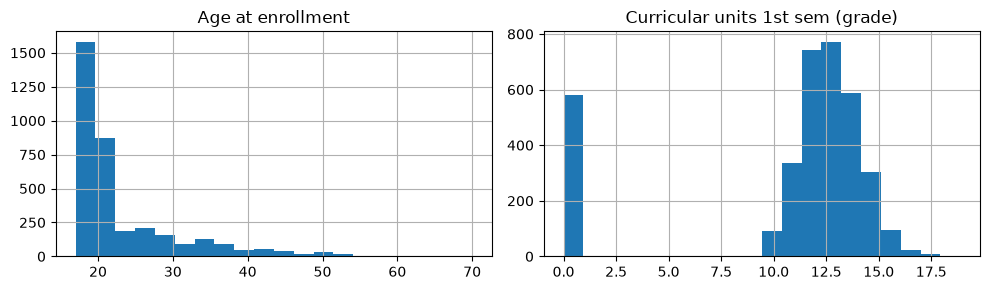

In [8]:
import matplotlib.pyplot as plt

cols = ["Age at enrollment", "Curricular units 1st sem (grade)"]

# descriptive statistics on training data only
print(Xtr[cols].describe().round(2))

print("\nFive oldest students:")
print(Xtr["Age at enrollment"].nlargest(5))

print("\nStudents with a 1st-semester grade of 0:",
      (Xtr["Curricular units 1st sem (grade)"] == 0).sum())

# Plot
Xtr[cols].hist(bins=20, figsize=(10, 3))
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

def add_features(data):
    # Work on a copy, so the same function is safe for either split
    result = data.copy()

   
    # A student passing few of their modules is plausibly at higher risk of dropping out.
    
    result["pass_rate_1st_sem"] = (
        result["Curricular units 1st sem (approved)"]
        / result["Curricular units 1st sem (enrolled)"].clip(lower=1)
    )

    # 2. No-grade flag: 1 if the student got no evaluated grade in the 1st semester.
   
    result["no_grade_1st_sem"] = (
        result["Curricular units 1st sem (grade)"] == 0
    ).astype(int)

    # 3. Age group: mature students may face different pressures (work, family).
    
    result["age_group"] = pd.cut(
        result["Age at enrollment"],
        bins=[0, 20, 25, 35, np.inf],
        labels=["17-20", "21-25", "26-35", "36+"],
    ).astype("object")

    # 4. Financial pressure score: 0 = no pressure, 3 = all three warning signs
    result["financial_pressure"] = (
        result["Debtor"]
        + (1 - result["Tuition fees up to date"])
        + (1 - result["Scholarship holder"])
    )

    return result

# The recipe is fixed (nothing learned from data), so apply it identically to both
Xtr = add_features(Xtr)
Xte = add_features(Xte)

# Keep the column lists from Step 5 up to date for encoding/scaling later
numeric_cols = numeric_cols + ["pass_rate_1st_sem", "financial_pressure"]
categorical_cols = categorical_cols + ["no_grade_1st_sem", "age_group"]

Xtr[["pass_rate_1st_sem", "no_grade_1st_sem", "age_group"]].head()


,pass_rate_1st_sem,no_grade_1st_sem,age_group
2283,0.909091,0,21-25
3874,0.000000,1,36+
2281,0.666667,0,21-25
817,1.000000,0,17-20
404,0.875000,0,17-20


In [10]:
# Research question: financial pressure vs academic performance
check = Xtr.assign(dropout=(y_train == "Dropout").astype(int))

print("Dropout rate by financial pressure score (0 = none, 3 = all warning signs):")
print(check.groupby("financial_pressure")["dropout"].agg(["mean", "count"]).round(2))

print("\nDropout rate by 1st-semester pass rate:")
bands = pd.cut(check["pass_rate_1st_sem"], [-0.01, 0, 0.5, 0.99, 1],
               labels=["passed none", "under half", "most", "all"])
print(check.groupby(bands, observed=True)["dropout"].agg(["mean", "count"]).round(2))

Dropout rate by financial pressure score (0 = none, 3 = all warning signs):
                    mean  count
financial_pressure             
0                   0.10    809
1                   0.29   2186
2                   0.70    365
3                   0.89    179

Dropout rate by 1st-semester pass rate:
                   mean  count
pass_rate_1st_sem             
passed none        0.79    582
under half         0.70    342
most               0.26   1218
all                0.09   1397


In [11]:
combo = pd.crosstab(
    check["financial_pressure"] >= 2,
    bands.isin(["passed none", "under half"]),
    values=check["dropout"], aggfunc="mean",
).round(2)
combo.index = ["Low financial pressure", "High financial pressure"]
combo.columns = ["Good academics", "Poor academics"]
combo

,Good academics,Poor academics
Low financial pressure,0.12,0.68
High financial pressure,0.59,0.91


In [12]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Binary columns: already 0/1, no encoding needed
binary_cols = [c for c in categorical_cols if Xtr[c].nunique() <= 2]

# Ordinal: age groups have a meaningful order, so give it explicitly
age_order = ["17-20", "21-25", "26-35", "36+"]
age_encoder = OrdinalEncoder(categories=[age_order])
Xtr["age_group"] = age_encoder.fit_transform(Xtr[["age_group"]]).ravel()
Xte["age_group"] = age_encoder.transform(Xte[["age_group"]]).ravel()
# Application order is already a ranked number (0 = first choice), so it stays as it is.

# Nominal: codes like Course 11 vs Course 5 have no order -> one-hot
nominal_cols = [c for c in categorical_cols
                if c not in binary_cols + ["age_group", "Application order"]]

nominal_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Learn which categories exist from training data only
train_nominal = pd.DataFrame(
    nominal_encoder.fit_transform(Xtr[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols),
    index=Xtr.index,
)
# A category that only appears in the test set is ignored rather than crashing
test_nominal = pd.DataFrame(
    nominal_encoder.transform(Xte[nominal_cols]),
    columns=nominal_encoder.get_feature_names_out(nominal_cols),
    index=Xte.index,
)

Xtr = pd.concat([Xtr.drop(columns=nominal_cols), train_nominal], axis=1)
Xte = pd.concat([Xte.drop(columns=nominal_cols), test_nominal], axis=1)

print("Binary (left as is):", binary_cols)
print("One-hot encoded:", nominal_cols)
print("\nShape after encoding - train:", Xtr.shape, " test:", Xte.shape)

Binary (left as is): ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'no_grade_1st_sem']
One-hot encoded: ['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]

Shape after encoding - train: (3539, 232)  test: (885, 232)


In [13]:
from sklearn.preprocessing import StandardScaler

# Scale only continuous / count / ordered columns.

scale_cols = numeric_cols + ["age_group", "Application order"]

print("Ranges before scaling:")
print(Xtr[scale_cols].agg(["min", "max"]).round(2).T)

# Learn mean and standard deviation from training data only
scaler = StandardScaler()
Xtr[scale_cols] = scaler.fit_transform(Xtr[scale_cols])

# Test set uses the same training values; it must not calculate new ones
Xte[scale_cols] = scaler.transform(Xte[scale_cols])

print("\nTraining data after scaling (mean should be ~0, std ~1):")
print(Xtr[scale_cols].agg(["mean", "std"]).round(2).T)

Ranges before scaling:
                                                  min    max
Age at enrollment                               17.00  70.00
Unemployment rate                                7.60  16.20
Inflation rate                                  -0.80   3.70
GDP                                             -4.06   3.51
Curricular units 1st sem (credited)              0.00  20.00
Curricular units 1st sem (enrolled)              0.00  26.00
Curricular units 1st sem (evaluations)           0.00  45.00
Curricular units 1st sem (approved)              0.00  26.00
Curricular units 1st sem (grade)                 0.00  18.88
Curricular units 1st sem (without evaluations)   0.00  12.00
pass_rate_1st_sem                                0.00   1.00
financial_pressure                               0.00   3.00
age_group                                        0.00   3.00
Application order                                0.00   9.00

Training data after scaling (mean should be ~0, std ~1):
    

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                   OrdinalEncoder, FunctionTransformer)
import numpy as np

# Row-wise feature engineering (Step 8), no learning involved 
def row_wise_features(data):
    result = data.copy()
    result["pass_rate_1st_sem"] = (
        result["Curricular units 1st sem (approved)"]
        / result["Curricular units 1st sem (enrolled)"].clip(lower=1)
    )
    result["no_grade_1st_sem"] = (result["Curricular units 1st sem (grade)"] == 0).astype(int)
    result["age_group"] = pd.cut(
        result["Age at enrollment"], bins=[0, 20, 25, 35, np.inf],
        labels=["17-20", "21-25", "26-35", "36+"],
    ).astype("object")
    return result

# Column groups, defined fresh from the original X_train
numeric_base = ["Age at enrollment", "Unemployment rate", "Inflation rate", "GDP"] + \
               [c for c in X_train.columns if c.startswith("Curricular units 1st sem")]
cat_base = [c for c in X_train.columns if c not in numeric_base]

numeric_pipe_cols = numeric_base + ["pass_rate_1st_sem", "Application order"]
binary_pipe_cols = [c for c in cat_base if X_train[c].nunique() <= 2] + ["no_grade_1st_sem"]
nominal_pipe_cols = [c for c in cat_base if c not in binary_pipe_cols + ["Application order"]]

# One mini-pipeline per column type (Steps 5, 9, 10)
numeric_steps = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
age_group_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(categories=[["17-20", "21-25", "26-35", "36+"]])),
    ("scale", StandardScaler()),
])
nominal_steps = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
binary_steps = SimpleImputer(strategy="most_frequent")  # already 0/1, just fill gaps

column_prep = ColumnTransformer([
    ("numeric", numeric_steps, numeric_pipe_cols),
    ("age_group", age_group_steps, ["age_group"]),
    ("nominal", nominal_steps, nominal_pipe_cols),
    ("binary", binary_steps, binary_pipe_cols),
])

preprocess = Pipeline([
    ("features", FunctionTransformer(row_wise_features)),
    ("columns", column_prep),
])

# Learn everything from training data only, then reuse it on the test set
X_train_ready = preprocess.fit_transform(X_train)
X_test_ready = preprocess.transform(X_test)

print("Pipeline output - train:", X_train_ready.shape, " test:", X_test_ready.shape)
print("Step-by-step version - train:", Xtr.shape, " test:", Xte.shape)

Pipeline output - train: (3539, 231)  test: (885, 231)
Step-by-step version - train: (3539, 232)  test: (885, 232)


In [15]:
# 1. Rows and columns
print("Train:", X_train_ready.shape, " Test:", X_test_ready.shape)

# 2. Any missing values left?
print("Missing values left:", np.isnan(X_train_ready).sum(), "in train;",
      np.isnan(X_test_ready).sum(), "in test")

# 3. Which categorical columns became several 0/1 columns?
onehot = preprocess.named_steps["columns"].named_transformers_["nominal"].named_steps["onehot"]
for col, cats in zip(nominal_pipe_cols, onehot.categories_):
    print(f"{col}: {len(cats)} columns")

# 4. Values learned from X_train
scaler = preprocess.named_steps["columns"].named_transformers_["numeric"].named_steps["scale"]
print("\nMeans learned from training data:")
print(pd.Series(scaler.mean_, index=numeric_pipe_cols).round(2))

Train: (3539, 231)  Test: (885, 231)
Missing values left: 0 in train; 0 in test
Marital status: 6 columns
Application mode: 18 columns
Course: 17 columns
Previous qualification: 17 columns
Nacionality: 19 columns
Mother's qualification: 28 columns
Father's qualification: 32 columns
Mother's occupation: 31 columns
Father's occupation: 41 columns

Means learned from training data:
Age at enrollment                                 23.25
Unemployment rate                                 11.58
Inflation rate                                     1.22
GDP                                                0.02
Curricular units 1st sem (credited)                0.72
Curricular units 1st sem (enrolled)                6.27
Curricular units 1st sem (evaluations)             8.29
Curricular units 1st sem (approved)                4.70
Curricular units 1st sem (grade)                  10.62
Curricular units 1st sem (without evaluations)     0.14
pass_rate_1st_sem                                  0.70
Ap

In [16]:
cols = numeric_base
comparison = pd.DataFrame({
    "median (all data)": X[cols].median(),
    "median (train only)": X_train[cols].median(),
    "mean (all data)": X[cols].mean(),
    "mean (train only)": X_train[cols].mean(),
}).round(2)
comparison

,median (all data),median (train only),mean (all data),mean (train only)
Age at enrollment,20.00,20.00,23.27,23.25
Unemployment rate,11.10,11.10,11.57,11.58
Inflation rate,1.40,1.40,1.23,1.22
GDP,0.32,0.32,0.00,0.02
Curricular units 1st sem (credited),0.00,0.00,0.71,0.72
Curricular units 1st sem (enrolled),6.00,6.00,6.27,6.27
Curricular units 1st sem (evaluations),8.00,8.00,8.30,8.29
Curricular units 1st sem (approved),5.00,5.00,4.71,4.70
Curricular units 1st sem (grade),12.29,12.32,10.64,10.62
Curricular units 1st sem (without evaluations),0.00,0.00,0.14,0.14


In [17]:
train_rows = df_clean.loc[X_train.index]
train_rows.groupby("Target")["Curricular units 2nd sem (approved)"].mean().round(2)

Target
Dropout     1.94
Enrolled    4.10
Graduate    6.16
Name: Curricular units 2nd sem (approved), dtype: float64